<a href="https://colab.research.google.com/github/Sebas-Atehortua/RiesgoOperacional-Fintech/blob/main/RiesgoOperacional_Fallas_Fintech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Riesgo operacional:** *Fallas en canales electrónicos*


En este código analizaremos el histórico de eventos de riesgo tecnológico registrados en canales electrónicos de la entidad financiera.

Cada registro corresponde a un día con fallas reportadas, con información sobre el número de transacciones fallidas (**Frecuencia**) y el valor económico promedio de las pérdidas generadas (**Severidad**).

### Metodología:

Aplicaremos la metodología de Riesgo Operacional con clusterización K-Means unidimensional para construir unas matrices de gestión, cuantificar la Pérdida Esperada (*PE*) y estimar el Operational Value at Risk (*OpVaR*) al 99.9% bajo dos escenarios comparativos:


*   **Riesgo Inherente**: exposición bruta sin controles (pérdidas no gestionadas)
*   **Riesgo Residual**:  exposición neta con controles activos (pérdidas gestionadas)





0. Se procede con la carga de las librerias de trabajo

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
def clusterizacion(Xi):
    """
    Apunte nota:

    Este es un algoritmo K-Means unidimensional que sirve para clasificar una variable
    numérica en 5 niveles ordenados de menor a mayor.

    Niveles resultantes:
        0 → Improbable / Insignificante
        1 → Posible    / Menor
        2 → Ocasional  / Moderado
        3 → Probable   / Mayor
        4 → Frecuente  / Catastrófico

    Parámetros:
        Xi : array numérico con los datos a clusterizar
    Retorno:
        XC : centroides finales de cada cluster (5 valores)
        nc : etiqueta de cluster asignada a cada dato
    """
    XC = np.random.choice(Xi, size=5)
    XC = np.sort(XC)           # Semillas ordenadas: garantiza nivel 0 = más bajo
    nc = np.zeros((len(Xi), 1))

    for k in range(len(Xi)):
        d = np.abs(XC - Xi[k])    # Distancia de cada dato a cada semilla
        nc[k] = np.argmin(d)      # Asigna el nivel del centroide más cercano
        nc2 = np.int32(nc[k])
        XC[nc2] = (XC[nc2] + Xi[k]) / 2   # Actualiza el centroide con el promedio

    return XC, nc

1. Se cargan los archivos de trabajo y se extraen las variables de interés.

In [60]:
nxl = '/content/drive/MyDrive/Proyecto EVERGREEN/Seguimiento #5/5. Riesgo Operacional FallasTecnológicas.xlsx'
XDB = pd.read_excel(nxl, sheet_name=0)

print("Vista previa de los datos cargados:")
print(XDB.head(5).to_string())
print(f"\nTotal de eventos registrados: {len(XDB)}")
print(f"Columnas: {list(XDB.columns)}")

np.random.seed(42) # Asignamos una semilla de reproductibilidad.

# Extracción de variables

Xf = np.array(XDB.iloc[:, 3])    # Transacciones Fallidas
Xs = np.abs(np.array(XDB.iloc[:, 4]))    # Valor Generado Promedio (Millones)

# Importante: se trabaja con valores absolutos de severidad para garantizar
# que las pérdidas siempre sean positivas en el modelo.

Xs = np.abs(Xs)

print(f"\nLa Frecuencia tiene un rango de: [{Xf.min()}, {Xf.max()}] | Con una media de: {Xf.mean():.2f} transacciones fallidas/día.")
print(f"La Severidad tiene un rango de: [{Xs.min():.4f}, {Xs.max():.4f}] | Con una media: {Xs.mean():.4f} millones COP")

Vista previa de los datos cargados:
      Fechas  Transacciones Diarias  Valor Transado (millones)  Transacciones Fallidas  Valor Generado Promedio (Millones)                                                                                                                                                                            Descripción Evento
0 2009-01-01                     80                    14.8058                       1                              0.5374                                                                     Errores visuales menores, problemas de usabilidad, notificaciones falsas, interrupciones breves de servicios no críticos.
1 2009-01-02                    105                    56.4721                       4                              1.1978  Errores en la interfaz de usuario, fallas en funcionalidades secundarias, problemas de rendimiento menores, incidentes de seguridad menores, interrupciones breves de servicios no críticos.
2 2009-01-03             

2. Se procede con la clusterización

In [61]:
# Se ingresan las transacciones fallidas y el valor generado promedio en la función de clusterización.

XCf, ncf = clusterizacion(Xf)
XCs, ncs = clusterizacion(Xs)

# Se calcula la Pérdida por Día Afectado (LDA)
LDA = Xf * Xs # Representa la exposición económica total en cada día de evento registrado.
XClda, nclda = clusterizacion(LDA)

# Construcción del dataframe:
df = pd.DataFrame(np.column_stack((Xf, ncf, Xs, ncs, LDA, nclda, XDB.iloc[:, 5])))
df.columns = ['Freq', 'Nivel_F', 'Sev', 'Nivel_S', 'LDA', 'Nivel_LDA', 'Descripcion']
df['Nivel_F'] = df['Nivel_F'].astype(int)
df['Nivel_S'] = df['Nivel_S'].astype(int)
df[['Freq','Sev','LDA']] = df[['Freq','Sev','LDA']].astype(float)
df.head()

print("\nResumen del DataFrame de trabajo:")
print(df[['Freq', 'Nivel_F', 'Sev', 'Nivel_S', 'LDA']].describe().round(4))


Resumen del DataFrame de trabajo:
           Freq   Nivel_F       Sev   Nivel_S       LDA
count  701.0000  701.0000  701.0000  701.0000  701.0000
mean     4.7532    1.5549    1.9296    1.0528    9.4511
std      2.9848    1.2990    2.1301    1.1244   13.7173
min      1.0000    0.0000    0.0842    0.0000    0.1423
25%      2.0000    0.0000    0.6313    0.0000    1.8800
50%      4.0000    1.0000    1.2240    1.0000    4.7912
75%      7.0000    3.0000    2.3439    2.0000   10.6197
max     16.0000    4.0000   17.3129    4.0000  111.0830


El resultado que buscamos es una etiqueta de nivel (0 a 4) para cada observación, que indica en qué categoría cae dentro de su propia distribución.

Estos niveles son los que determinan la posición (fila, columna) de cada evento dentro de las matrices de riesgo operacional.

### 3. Se construyen las matrices

Se construyen **cuatro matrices integradas en una cuadrícula 5×5**, donde las filas representan niveles de Frecuencia y las columnas niveles de Severidad.

In [62]:
etiquetas = ['Improbable\n(N0)','Posible\n(N1)','Ocasional\n(N2)','Probable\n(N3)','Frecuente\n(N4)']

3.1. Matriz de frecuencia (MEf)

Acumula el total de transacciones fallidas en cada celda, mayor valor indica que los eventos de esa combinación de niveles generaron mayores fallos.

In [63]:
MEf = np.zeros((5, 5))
MEs = np.zeros((5, 5))

for k in range(len(Xf)):
    nf = int(df.iloc[k, 1])    # Nivel de frecuencia → determina la FILA
    nc = int(df.iloc[k, 3])    # Nivel de severidad  → determina la COLUMNA
    MEf[nf, nc] = MEf[nf, nc] + Xf[k]            # Acumula transacciones fallidas
    MEs[nf, nc] = (MEs[nf, nc] + Xs[k]) / 2      # Promedia la severidad de la celda

3.2. Matriz de pérdidas agregadas

Es el producto celda por celda de la Matriz de Frecuencia por la Matriz de Severidad: MLP = MEf × MEs, que representa la exposición económica total acumulada en cada celda. Es la base para cuantificar el Riesgo Inherente de la entidad.

In [64]:
MLP = MEf * MEs

3.3. Matriz de impacto

Esta asigna un nivel de impacto institucional (1 = riesgo bajo → 5 = riesgo catastrófico) a cada celda, independientemente de los datos que se obtengan.

In [65]:
MI = np.array([[1,1,1,2,2],
               [1,2,2,3,3],
               [1,2,3,3,4],
               [2,3,3,4,4],
               [2,3,4,4,5]])

3.4. Matriz de gestión

Modela la reducción del riesgo mediante controles activos. El nivel representa la intensidad de la intervención, siendo:
*   NG = 1 → Monitoreo rutinario (alertas automáticas, protocolos básicos)
*   NG = 2 → Gestión activa (planes de contingencia, redundancias de sistema)
*   NG = 3 → Intervención avanzada (recuperación ante desastres, auditorías)
*   NG = 4 → Control total (transformación tecnológica, rediseño de proceso)

Las celdas de nivel 1 y 5 no se modifican (ya que riesgo ya es mínimo y un valor alto requiere una decisión directiva que está fuera del modelo)

El mayor NG implica mayor atención y recursos, lo que traduce en menor pérdida esperada residual para la entidad.

Ingresar el Nivel de Gestión — NG (1, 2, 3 ó 4): 1


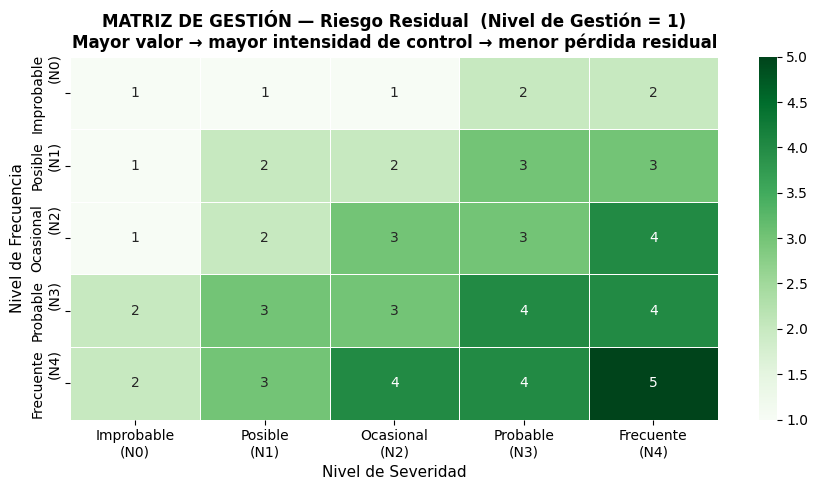

In [66]:
NG = int(input("Ingresar el Nivel de Gestión — NG (1, 2, 3 ó 4): "))

MG = np.copy(MI)
for i in range(5):
    for j in range(5):
        if MG[i, j] > 1 and MG[i, j] < 5:
            MG[i, j] = MG[i, j] * NG

# Visualizamos:

plt.figure(figsize=(9, 5))
sns.heatmap(MG, annot=True, fmt='.0f', cmap='Greens',
            xticklabels=etiquetas, yticklabels=etiquetas,
            linewidths=0.5, linecolor='white')
plt.xlabel('Nivel de Severidad', fontsize=11)
plt.ylabel('Nivel de Frecuencia', fontsize=11)
plt.title(f'MATRIZ DE GESTIÓN — Riesgo Residual  (Nivel de Gestión = {NG})\n'
          f'Mayor valor → mayor intensidad de control → menor pérdida residual',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

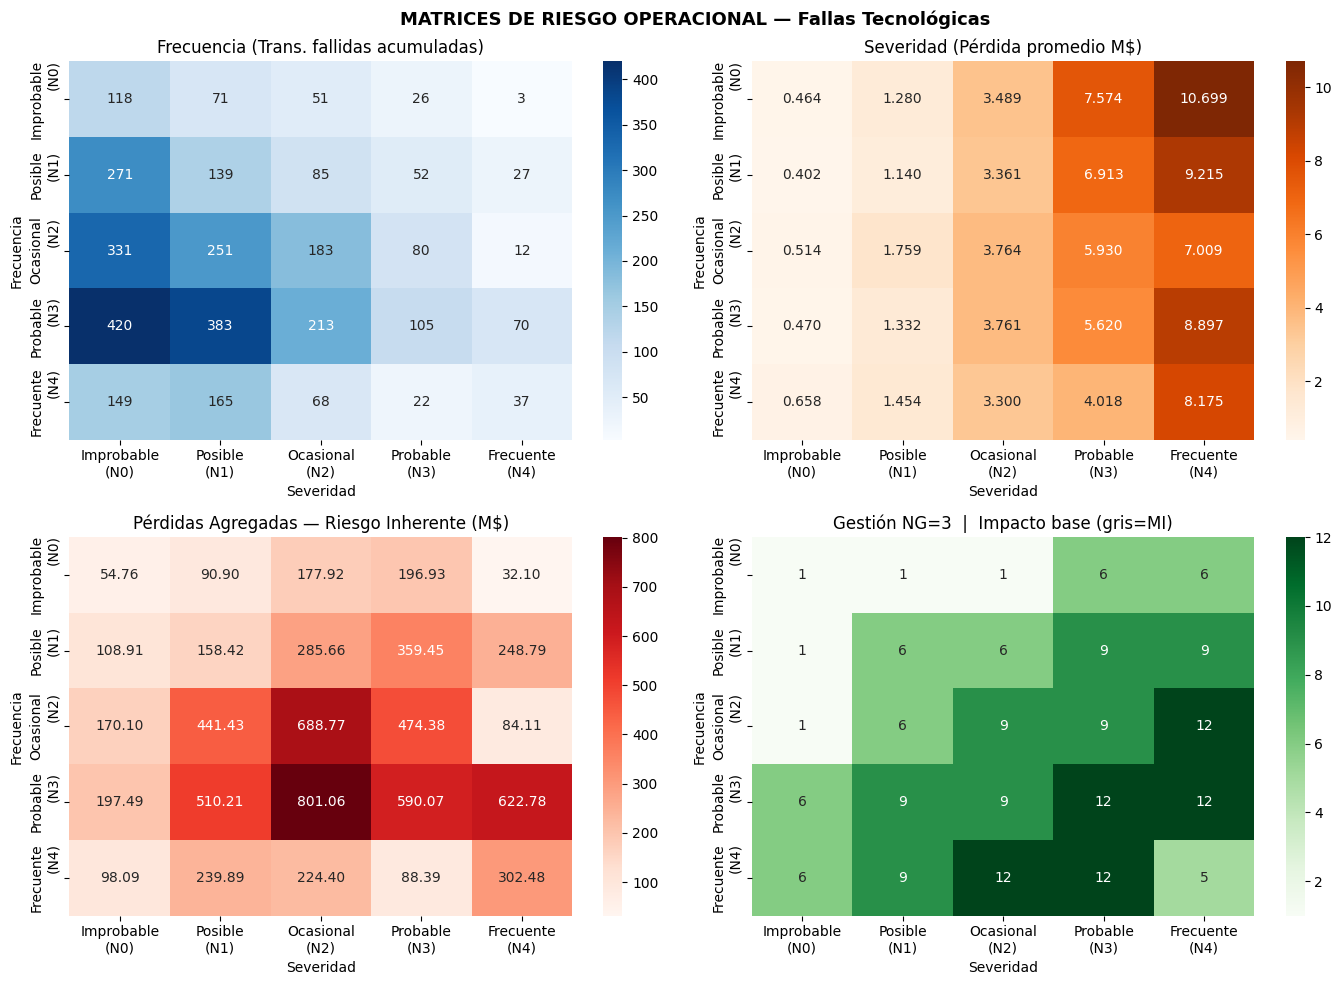

In [38]:
# Visualizamos las cuatro matrices en una cuadrícula
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.heatmap(MEf, annot=True, fmt='.0f',  cmap='Blues',   ax=axes[0,0],
            xticklabels=ejes, yticklabels=ejes).set_title('Frecuencia (Trans. fallidas acumuladas)')
sns.heatmap(MEs, annot=True, fmt='.3f',  cmap='Oranges', ax=axes[0,1],
            xticklabels=ejes, yticklabels=ejes).set_title('Severidad (Pérdida promedio M$)')
sns.heatmap(MLP, annot=True, fmt='.2f',  cmap='Reds',    ax=axes[1,0],
            xticklabels=ejes, yticklabels=ejes).set_title('Pérdidas Agregadas — Riesgo Inherente (M$)')
sns.heatmap(MG,  annot=True, fmt='.0f',  cmap='Greens',  ax=axes[1,1],
            xticklabels=ejes, yticklabels=ejes).set_title(f'Gestión NG={NG}  |  Impacto base (gris=MI)')

for ax in axes.flat:
    ax.set_xlabel('Severidad')
    ax.set_ylabel('Frecuencia')

plt.suptitle('Matrices de riesgo para la operación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Pérdida esperada

Se calculan cuatro niveles de PE, cada uno incorpora información adicional, permitiendo comparar el impacto de la frecuencia, el nivel de impacto y los controles de gestión sobre la exposición.

In [40]:
print("\n" + "="*65)
print("  Estimación cuantitativa de la pérdida esperada")
print("="*65)

ps  = np.mean(MEs) # Promedio simple de severidad
pp  = np.round(np.sum(MEf * MEs) / np.sum(MEf), 4) # Promedio ponderado por frecuencia
pnr = np.sum(MEf * MEs * MI) / np.sum(MEf * MI) # PE ponderada con nivel de impacto (Riesgo Inherente)
png = np.sum(MEf * MEs * MI) / np.sum(MEf * MG) # PE ponderada con gestión (Riesgo Residual)

print("PE simple (sin ponderar):             ", round(ps,  4), "M COP")
print("PE ponderada por frecuencia:          ", round(pp,  4), "M COP")
print("PE Riesgo Inherente (con MI):         ", round(pnr, 4), "M COP")
print(f"PE Riesgo Residual  (con MG, NG={NG}):  ", round(png, 4), "M COP")
print(f"Reducción por gestión:                {round(pnr-png,4)} M COP  ({round((pnr-png)/pnr*100,1)}%)")


  Estimación cuantitativa de la pérdida esperada
PE simple (sin ponderar):              4.0478 M COP
PE ponderada por frecuencia:           2.1751 M COP
PE Riesgo Inherente (con MI):          2.8118 M COP
PE Riesgo Residual  (con MG, NG=3):   1.0302 M COP
Reducción por gestión:                1.7816 M COP  (63.4%)


### 5. Operational value at Risk (OpVaR)

Este indicador mide la pérdida máxima que la entidad podría enfrentar con un nivel de confianza del 99.9%. Solo el 0.1% de los escenarios podría generar pérdidas superiores a este valor.

Se comparan dos escenarios:
*   Escenario A: Riesgo Inherente: Es la distribución real de LDA sin ajuste
*   Escenario B: Riesgo Residual: Es la LDA ajustada por el factor de reducción de gestión (MI / MG), y muestra la eficacia de los controles activos.


  Escenario A: Riesgo Inherente  (Pérdidas que no son gestionadas)
  Pérdida Esperada (PE):          9.4511  millones COP
  OpVaR al 99.9%:                 102.9021  millones COP
  Pérdida máxima observada:       111.0830  millones COP
  Relación OpVaR / PE:            10.89x
  Interpretación: La entidad necesita reservar al menos 102.9021 millones COP
    como capital regulatorio para cubrir eventos extremos.

  ESCENARIO B — RIESGO RESIDUAL (Pérdidas Gestionadas  NG=3)
  Pérdida Esperada (PE):          4.0924  millones COP
  OpVaR al 99.9%:                 79.8370  millones COP
  Pérdida máxima ajustada:        82.1007  millones COP
  Relación OpVaR / PE:            19.51x
  Con gestión NG=3, la entidad puede reducir su capital
    regulatorio a 79.8370 millones COP.

  Comparativo escenarios A vs. B
  Métrica                               Inherente    Residual   Reducción
  ─────────────────────────────────────────────────────────────────
  Pérdida Esperada (PE)                    

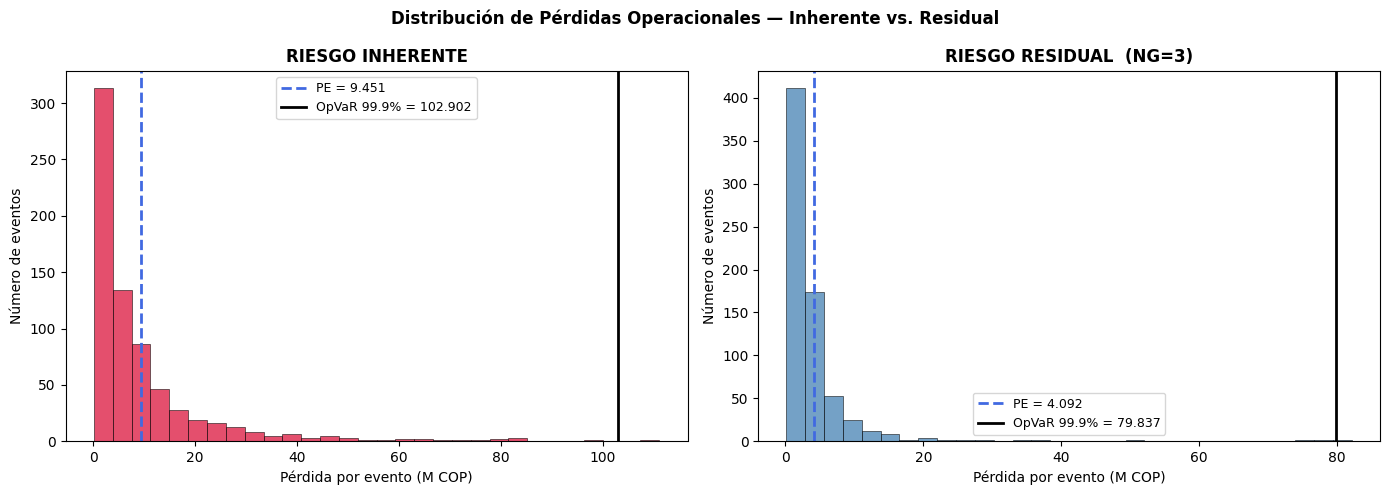

In [48]:
# ESCENARIO A — distribución real de LDA, sin ajuste
LDA_abs = np.abs(LDA)

opvar_A    = np.percentile(LDA_abs, 99.9)
pe_A       = np.mean(LDA_abs)
pmax_A     = LDA_abs.max()

print("\n" + "="*65)
print("  Escenario A: Riesgo Inherente  (Pérdidas que no son gestionadas)")
print("="*65)
print(f"  Pérdida Esperada (PE):          {pe_A:.4f}  millones COP")
print(f"  OpVaR al 99.9%:                 {opvar_A:.4f}  millones COP")
print(f"  Pérdida máxima observada:       {pmax_A:.4f}  millones COP")
print(f"  Relación OpVaR / PE:            {opvar_A/pe_A:.2f}x")
print(f"  Interpretación: La entidad necesita reservar al menos {opvar_A:.4f} millones COP")
print(f"    como capital regulatorio para cubrir eventos extremos.")

# ESCENARIO B — LDA ajustada evento a evento por el factor de reducción MI/MG
LDA_res = np.zeros(len(Xf))
for k in range(len(Xf)):
    nf = int(df.iloc[k, 1])
    nc = int(df.iloc[k, 3])
    LDA_res[k] = LDA[k] * (MI[nf, nc] / MG[nf, nc])

opvar_B = np.percentile(LDA_res, 99.9)
pe_B    = np.mean(LDA_res)

print("\n" + "="*65)
print(f"  ESCENARIO B — RIESGO RESIDUAL (Pérdidas Gestionadas  NG={NG})")
print("="*65)
print(f"  Pérdida Esperada (PE):          {pe_B:.4f}  millones COP")
print(f"  OpVaR al 99.9%:                 {opvar_B:.4f}  millones COP")
print(f"  Pérdida máxima ajustada:        {pmax_B:.4f}  millones COP")
print(f"  Relación OpVaR / PE:            {opvar_B/pe_B:.2f}x")
print(f"  Con gestión NG={NG}, la entidad puede reducir su capital")
print(f"    regulatorio a {opvar_B:.4f} millones COP.")


# ── COMPARATIVO FINAL ──
reduccion_opvar = opvar_A - opvar_B
reduccion_pe_b  = pe_A - pe_B
print("\n" + "="*65)
print("  Comparativo escenarios A vs. B")
print("="*65)
print(f"  {'Métrica':<35}  {'Inherente':>10}  {'Residual':>10}  {'Reducción':>10}")
print(f"  {'─'*65}")
print(f"  {'Pérdida Esperada (PE)':<35}  {pe_A:>10.4f}  {pe_B:>10.4f}  {reduccion_pe_b:>10.4f}")
print(f"  {'OpVaR 99.9%':<35}  {opvar_A:>10.4f}  {opvar_B:>10.4f}  {reduccion_opvar:>10.4f}")
print(f"  {'Pérdida Máxima':<35}  {pmax_A:>10.4f}  {pmax_B:>10.4f}  {pmax_A-pmax_B:>10.4f}")
print(f"\n  Capital regulatorio liberado por gestión: {reduccion_opvar:.4f} millones COP")
print(f"  Eficiencia del control (% reducción OpVaR): {reduccion_opvar/opvar_A*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, datos, opvar, pe, color, titulo in [
    (axes[0], LDA,     opvar_A, pe_A, 'crimson',   'RIESGO INHERENTE'),
    (axes[1], LDA_res, opvar_B, pe_B, 'steelblue', f'RIESGO RESIDUAL  (NG={NG})')]:

    ax.hist(datos, bins=30, color=color, alpha=0.75, edgecolor='black', linewidth=0.5)
    ax.axvline(pe,    color='royalblue', linestyle='--', linewidth=2, label=f'PE = {pe:.3f}')
    ax.axvline(opvar, color='black',     linestyle='-',  linewidth=2, label=f'OpVaR 99.9% = {opvar:.3f}')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Pérdida por evento (M COP)')
    ax.set_ylabel('Número de eventos')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de Pérdidas Operacionales — Inherente vs. Residual',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 6. Herramienta de auditoría

Esta herramienta permite seleccionar cualquier celda de la matriz en selectores desplegables (Frecuencia y Severidad) que muestran en tiempo real todos los eventos registrados en la celda seleccionada, entregados de la siguiente forma:

   • Fecha, frecuencia, severidad y LDA de cada evento
   • Descripción completa del tipo de evento registrado
   • Indicadores resumidos: total de eventos, LDA total y promedio
   • Nivel de impacto y factor de reducción para ese cuadrante

In [57]:
niveles = {0:'N0 — Improbable', 1:'N1 — Posible', 2:'N2 — Ocasional',
           3:'N3 — Probable',   4:'N4 — Frecuente'}

dd_f = widgets.Dropdown(options=[(v,k) for k,v in niveles.items()], value=2,
                        description='Frecuencia:', style={'description_width':'120px'},
                        layout={'width':'400px'})
dd_s = widgets.Dropdown(options=[(v,k) for k,v in niveles.items()], value=2,
                        description='Severidad:',  style={'description_width':'120px'},
                        layout={'width':'400px'})
out  = widgets.Output()

def filtrar(cambio):
    with out:
        clear_output()
        nf, ns  = dd_f.value, dd_s.value
        mask    = (df['Nivel_F'] == nf) & (df['Nivel_S'] == ns)
        eventos = df[mask].copy()
        idx     = np.where(mask)[0]

        print(f"\n{'═'*65}")
        print(f"  CELDA [{nf},{ns}]  ·  {niveles[nf]}  ×  {niveles[ns]}")
        print(f"{'═'*65}")

        if len(eventos) == 0:
            print("  ⚠  Sin eventos registrados para esta combinación.")
            return

        print(f"  Eventos en celda:    {len(eventos)}")
        print(f"  LDA total:           {eventos['LDA'].sum():.4f}  M COP")
        print(f"  LDA promedio:        {eventos['LDA'].mean():.4f}  M COP")
        print(f"  Nivel de impacto MI: {MI[nf,ns]}  |  Gestión MG: {MG[nf,ns]}")
        print(f"  Factor reducción:    {MI[nf,ns]/MG[nf,ns]:.4f}")
        print(f"\n  {'#':<4} {'Fecha':<12} {'Freq':>6} {'Sev':>9} {'LDA':>9}")
        print(f"  {'─'*45}")

        for i, k in enumerate(idx):
            fila = df.iloc[k]
            try:
                fecha = pd.to_datetime(XDB.iloc[k,0], origin='1899-12-30', unit='D').strftime('%d/%m/%Y')
            except:
                fecha = str(XDB.iloc[k,0])[:10]
            print(f"  {i+1:<4} {fecha:<12} {fila['Freq']:>6.0f} {fila['Sev']:>9.4f} {fila['LDA']:>9.4f}")

        print(f"\n  Tipo de evento: {str(df.iloc[idx[0]]['Descripcion'])}")
        print(f"  Contribución al portafolio total: {eventos['LDA'].sum()/df['LDA'].sum()*100:.2f}%")

# Vincular los selectores a la función de filtrado
dd_f.observe(filtrar, names='value')
dd_s.observe(filtrar, names='value')

# Mostrar la interfaz de usuario
display(dd_f, dd_s, out)

# Ejecutar el filtro con los valores iniciales para mostrar resultado de inmediato
filtrar(None)

Dropdown(description='Frecuencia:', index=2, layout=Layout(width='400px'), options=(('N0 — Improbable', 0), ('…

Dropdown(description='Severidad:', index=2, layout=Layout(width='400px'), options=(('N0 — Improbable', 0), ('N…

Output()

In [67]:
print("\n" + "="*65)
print("  ANÁLISIS DE RESULTADOS — SÍNTESIS GERENCIAL")
print("="*65)

print(f"""
1. ESTRUCTURA DEL RIESGO (MATRICES):
   La clusterización K-Means identificó que la mayoría de eventos
   de fallo en canales electrónicos se concentra en los niveles de
   frecuencia media (Ocasional) combinados con severidad baja a media.
   Sin embargo, los eventos catastróficos —aunque infrecuentes— dominan
   la exposición económica total de la Matriz de Pérdidas Agregadas.

2. PÉRDIDA ESPERADA:
   • Promedio simple de severidad:             {ps:.4f} M COP
   • PE ponderada (sin impacto):               {pp:.4f} M COP
   • PE Riesgo Inherente (con MI):             {pnr:.4f} M COP
   • PE Riesgo Residual  (con MG, NG={NG}):    {png:.4f} M COP

   La incorporación de la Matriz de Impacto aumenta la PE al ponderar
   los eventos estratégicamente relevantes. La gestión NG={NG} genera
   una reducción de {pnr-png:.4f} M COP ({(pnr-png)/pnr*100:.1f}%) sobre la PE inherente.

3. OpVaR AL 99.9%:
   • Riesgo Inherente:  {opvar_A:.4f} M COP  → Capital regulatorio sin controles
   • Riesgo Residual:   {opvar_B:.4f} M COP  → Capital regulatorio con controles
   • Capital liberado:  {opvar_A-opvar_B:.4f} M COP  ({(opvar_A-opvar_B)/opvar_A*100:.1f}% de eficiencia)

   El desplazamiento hacia la izquierda de la distribución de Riesgo
   Residual confirma que los controles reducen significativamente la
   cola pesada de la distribución de pérdidas. Esto se traduce en un
   menor requerimiento de capital regulatorio según Basilea III.

4. HERRAMIENTA DE AUDITORÍA:
   El filtro dinámico permite al analista navegar por las 25 celdas
   de la matriz para identificar los eventos que componen cada nivel
   de riesgo. Las celdas de mayor contribución al portafolio deben
   ser objeto prioritario de planes de acción y seguimiento continuo.

5. RECOMENDACIÓN:
   Se recomienda mantener el Nivel de Gestión en NG ≥ 2 para los
   cuadrantes de impacto 3 y 4 de la Matriz de Impacto, priorizando
   los sistemas de redundancia y recuperación ante fallos críticos
   en App Móvil y Sucursal Virtual, que concentran el mayor volumen
   de transacciones de la entidad.
""")


  ANÁLISIS DE RESULTADOS — SÍNTESIS GERENCIAL

1. ESTRUCTURA DEL RIESGO (MATRICES):
   La clusterización K-Means identificó que la mayoría de eventos
   de fallo en canales electrónicos se concentra en los niveles de
   frecuencia media (Ocasional) combinados con severidad baja a media.
   Sin embargo, los eventos catastróficos —aunque infrecuentes— dominan
   la exposición económica total de la Matriz de Pérdidas Agregadas.
 
2. PÉRDIDA ESPERADA:
   • Promedio simple de severidad:             4.0478 M COP
   • PE ponderada (sin impacto):               2.1751 M COP
   • PE Riesgo Inherente (con MI):             2.8118 M COP
   • PE Riesgo Residual  (con MG, NG=1):    1.0302 M COP
   
   La incorporación de la Matriz de Impacto aumenta la PE al ponderar
   los eventos estratégicamente relevantes. La gestión NG=1 genera
   una reducción de 1.7816 M COP (63.4%) sobre la PE inherente.
 
3. OpVaR AL 99.9%:
   • Riesgo Inherente:  102.9021 M COP  → Capital regulatorio sin controles
   • Rie